In [ ]:
import os, sys, argparse, torch, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

np.random.seed(2025)
torch.manual_seed(2025)
warnings.filterwarnings("ignore")
from src.ndp import NDP
%matplotlib inline

data_path = "datasets/5Gtraffic/number_value_cell_2_beam_19.csv"
split_ratio = 0.8
input_window = 36
pred_window = 36
hidden_dim = 256
n_layers = 6
time_steps = 25
epochs = 10
batch_size = 64
lr = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
f"🖥️ 使用设备: {device}"

'🖥️ 使用设备: cuda'

In [4]:
df = pd.read_csv(data_path, parse_dates=["date"])
scaler = StandardScaler()
data = scaler.fit_transform(df[["value", "ma_value", "lg_ma_value"]].values)
dates = df["date"].values
f"✅ 数据预处理完成，标准化后形状: {data.shape}"

'✅ 数据预处理完成，标准化后形状: (645, 3)'

In [5]:
n_samples = len(data)
tr_idx = np.arange(n_samples)
np.random.shuffle(tr_idx)
train_size = int(n_samples * split_ratio)
te_idx = tr_idx[train_size:]
train_data, test_data, train_dates, test_dates = (
    data[tr_idx],
    data[te_idx],
    dates[tr_idx],
    dates[te_idx],
)

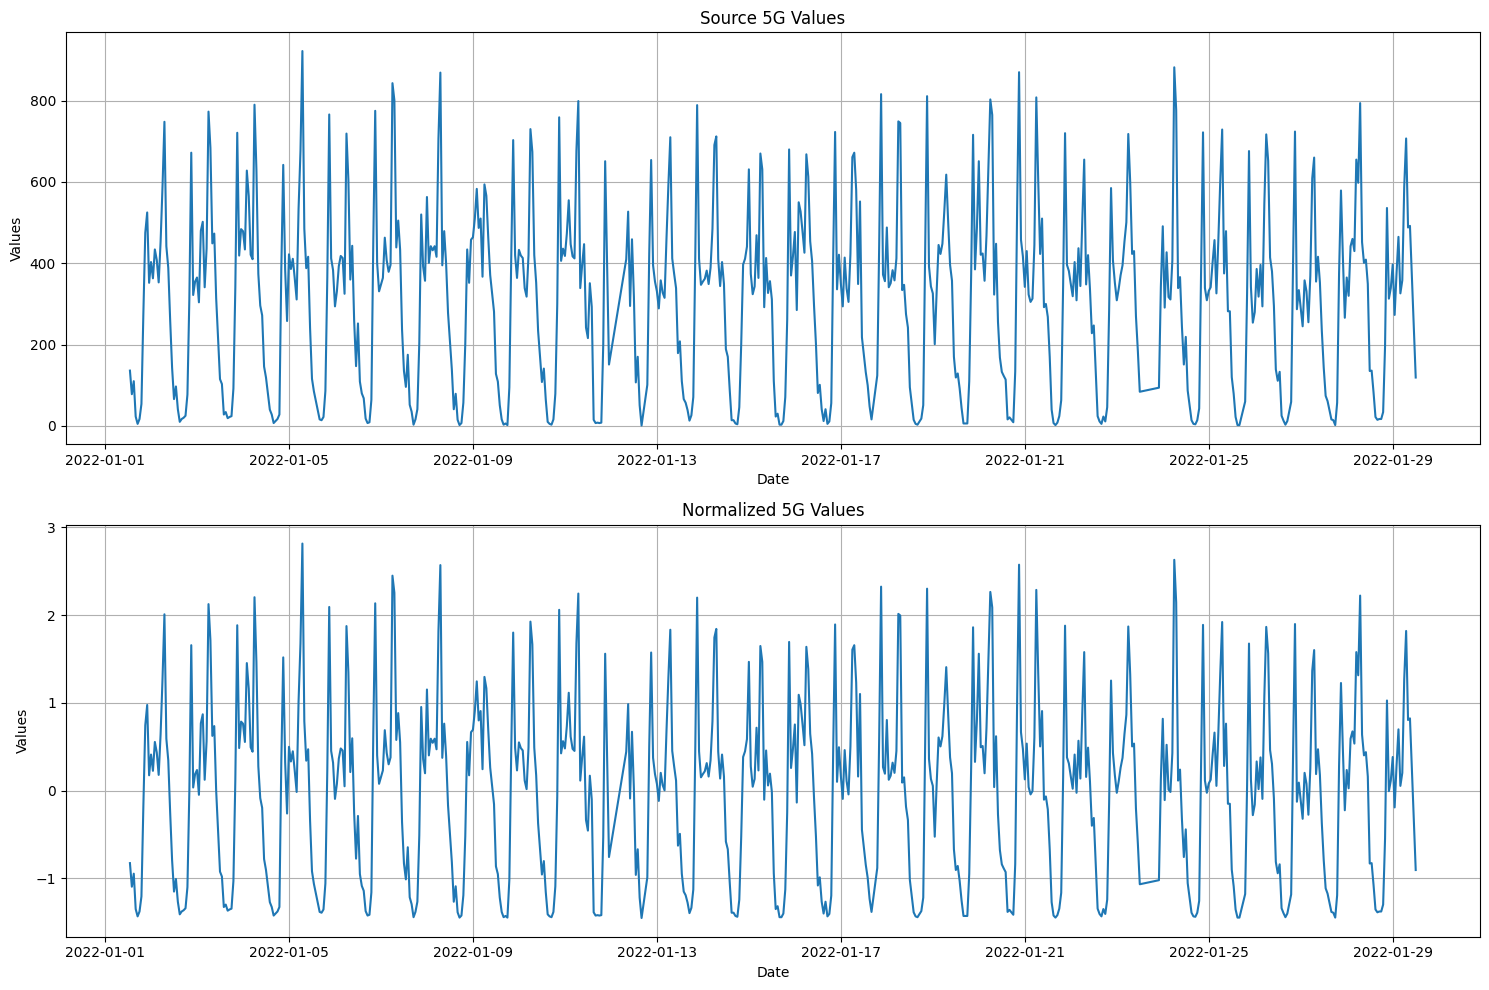

In [6]:
# 数据分析：查看原始数据与标准化后数据的分布
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(df["date"], df["value"])
plt.title("Source 5G Values")
plt.xlabel("Date")
plt.ylabel("Values")
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(dates, data[:, 0])
plt.title("Normalized 5G Values")
plt.xlabel("Date")
plt.ylabel("Values")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_window=12, pred_window=24):
        self.data = data
        self.input_window = input_window
        self.pred_window = pred_window
        self.samples = []
        total_len = len(self.data)
        for i in range(total_len - self.input_window - self.pred_window + 1):
            x_seq = self.data[i : i + self.input_window]
            y_seq = self.data[
                i + self.input_window : i + self.input_window + self.pred_window, 0:1
            ]
            self.samples.append((x_seq, y_seq))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.FloatTensor(x), torch.FloatTensor(y)

train_dataset = TimeSeriesDataset(train_data, input_window, pred_window)
test_dataset = TimeSeriesDataset(test_data, input_window, pred_window)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"训练模式: 多样本")
print(f"预测时长: 长期")
print(f"输入窗口: {input_window} 小时")
print(f"预测窗口: {pred_window} 小时")
print(f"输入特征维度: {train_data.shape[1]}")

训练模式: 多样本
预测时长: 长期
输入窗口: 36 小时
预测窗口: 36 小时
输入特征维度: 3


In [ ]:
input_dim = train_data.shape[1]  # 特征维度
model = NDP(
    in_dim=input_dim,
    time_step=time_steps,
    device=device,
    hidden=hidden_dim,
    n_layers=n_layers,
)

optimizer = torch.optim.Adam(model.model.parameters(), lr=lr)

In [15]:
def train(model, train_loader, optimizer, device, epoch):
    model.model.train()
    total_loss = 0

    for batch_idx, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()
        loss = model.loss(x.to(device), y.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"[Train] Epoch: {epoch}, Loss: {avg_loss:.6f}")
    return avg_loss


@torch.no_grad()
def evaluate(model, test_loader, device):
    model.model.eval()
    all_preds, all_targets = [], []
    for x, y in test_loader:
        y_pred = model.sample(x.to(device), y.size(1))
        all_preds.append(y_pred)
        all_targets.append(y.to(device))
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    mse = torch.mean((all_preds - all_targets) ** 2).item()
    mae = torch.mean(torch.abs(all_preds - all_targets)).item()
    print(f"[Val] MSE: {mse:.4f}, MAE: {mae:.4f}")
    return mse, mae, all_preds.cpu().numpy(), all_targets.cpu().numpy()


best_mse = float("inf")
best_model = None
train_losses, val_mses, val_maes = [], [], []

for epoch in range(1, epochs + 1):
    train_loss = train(model, train_loader, optimizer, device, epoch)
    train_losses.append(train_loss)
    mse, mae, _, _ = evaluate(model, test_loader, device)
    val_mses.append(mse)
    val_maes.append(mae)
    if mse < best_mse:
        best_mse = mse
        best_model = model.model
        print(f"💾 新的最佳模型 (MSE: {best_mse:.4f})")

[Train] Epoch: 1, Loss: 1.044931
[Val] MSE: 2.6080, MAE: 1.2725
💾 新的最佳模型 (MSE: 2.6080)
[Train] Epoch: 2, Loss: 0.997123
[Val] MSE: 2.5424, MAE: 1.2674
💾 新的最佳模型 (MSE: 2.5424)
[Train] Epoch: 3, Loss: 1.000196
[Val] MSE: 2.5322, MAE: 1.2579
💾 新的最佳模型 (MSE: 2.5322)
[Train] Epoch: 4, Loss: 0.977595
[Val] MSE: 2.3798, MAE: 1.2211
💾 新的最佳模型 (MSE: 2.3798)
[Train] Epoch: 5, Loss: 0.962367
[Val] MSE: 2.2935, MAE: 1.2264
💾 新的最佳模型 (MSE: 2.2935)
[Train] Epoch: 6, Loss: 0.971626
[Val] MSE: 2.0795, MAE: 1.1629
💾 新的最佳模型 (MSE: 2.0795)
[Train] Epoch: 7, Loss: 0.934882
[Val] MSE: 2.1951, MAE: 1.1852
[Train] Epoch: 8, Loss: 0.942372
[Val] MSE: 2.0773, MAE: 1.1522
💾 新的最佳模型 (MSE: 2.0773)
[Train] Epoch: 9, Loss: 0.947940
[Val] MSE: 2.1409, MAE: 1.1611
[Train] Epoch: 10, Loss: 0.921853
[Val] MSE: 2.1393, MAE: 1.1723


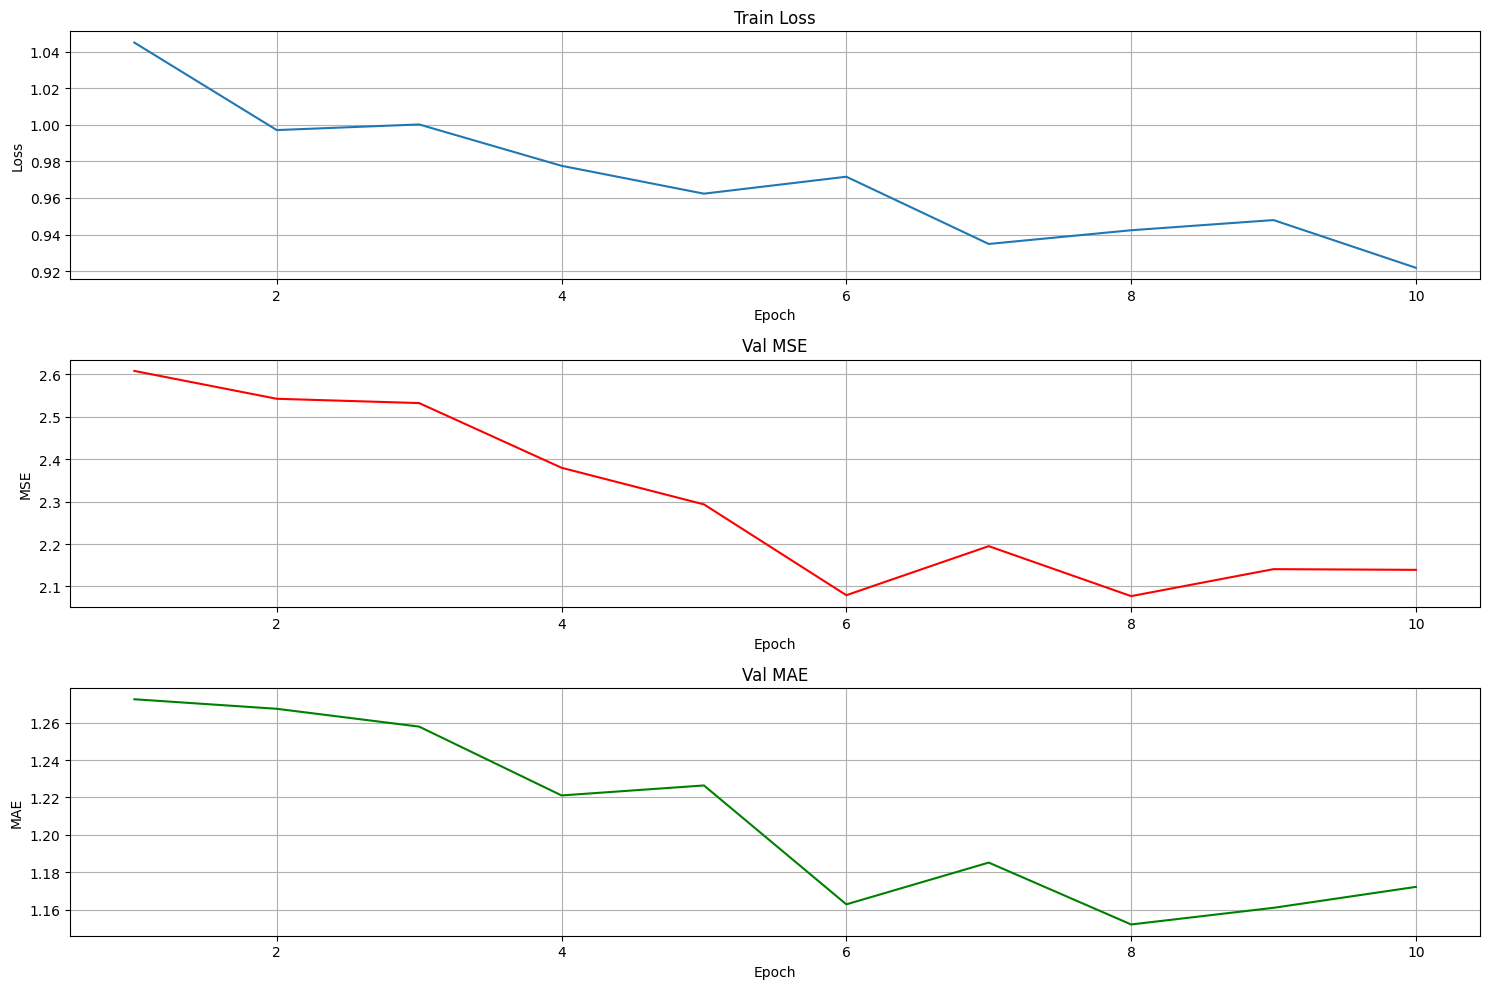

In [16]:
# 绘制训练曲线
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(range(1, epochs + 1), train_losses)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(range(1, epochs + 1), val_mses, "r-")
plt.title("Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(range(1, epochs + 1), val_maes, "g-")
plt.title("Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)

plt.tight_layout()
plt.show()

[Val] MSE: 2.0854, MAE: 1.1415


/tmp/ipykernel_2701051/2718606455.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(


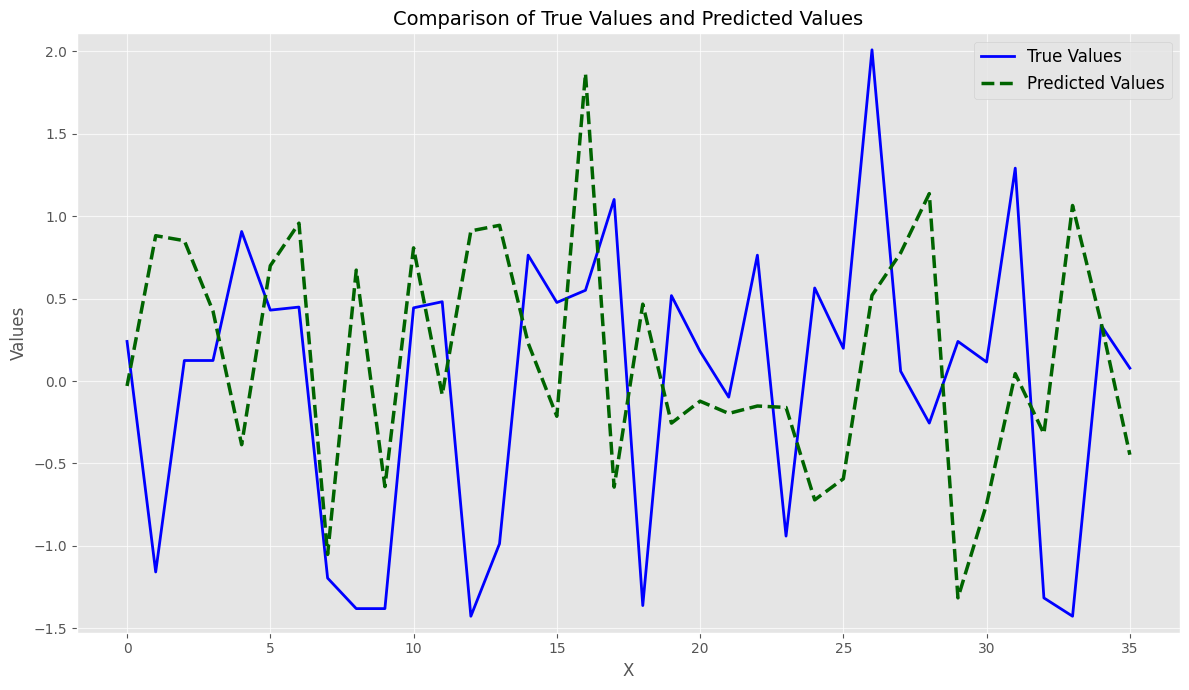

样本 10 的评估指标:
MSE: 1.4301
MAE: 0.9973
RMSE: 1.1959


In [21]:
mse, mae, preds, targets = evaluate(model, test_loader, device)

sample_idx = 10 
pred_sample = preds[
    sample_idx
].flatten()  # 将形状从 [pred_window, 1] 转换为 [pred_window]
target_sample = targets[sample_idx].flatten()
x_points = np.arange(len(pred_sample))
plt.style.use("ggplot")
plt.figure(figsize=(12, 7))
plt.grid(True, linestyle="-", alpha=0.7)

plt.plot(x_points, target_sample, "b-", label="True Values", linewidth=2, markersize=6)
plt.plot(
    x_points,
    pred_sample,
    "g--",
    label="Predicted Values",
    linewidth=2.5,
    markersize=6,
    markeredgewidth=2,
    color="darkgreen",
)

# 添加标题和标签
plt.title("Comparison of True Values and Predicted Values", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("Values", fontsize=12)

# 添加图例
plt.legend(fontsize=12, loc="upper right")

# 设置Y轴范围，使其与您的图像类似
ymin = min(min(pred_sample), min(target_sample)) - 0.1
ymax = max(max(pred_sample), max(target_sample)) + 0.1
plt.ylim([ymin, ymax])

# 显示图像
plt.tight_layout()
plt.show()

# 计算并显示评估指标
print(f"样本 {sample_idx} 的评估指标:")
print(f"MSE: {np.mean((pred_sample - target_sample)**2):.4f}")
print(f"MAE: {np.mean(np.abs(pred_sample - target_sample)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((pred_sample - target_sample)**2)):.4f}")

In [ ]:
def noise_robustness_test(
    model,
    test_data,
    test_dates,
    input_window,
    pred_window,
    device,
    noise_levels=[0.01, 0.02, 0.03, 0.04],
    batch_size=64,
):
    results = []

    for noise_level in noise_levels:
        print(f"\n🧪 噪声水平 {noise_level} 的鲁棒性测试")

        test_data_noisy = test_data.copy()
        test_data_noisy += np.random.normal(0, noise_level, test_data.shape)

        test_dataset = TimeSeriesDataset(test_data_noisy, input_window, pred_window)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        mse, mae, preds, targets = evaluate(model, test_loader, device)
        results.append(
            {
                "noise_level": noise_level,
                "mse": mse,
                "mae": mae,
                "preds": preds,
                "targets": targets,
            }
        )

    return results

noise_results = noise_robustness_test(
    model,
    test_data,
    test_dates,
    input_window,
    pred_window,
    device,
    noise_levels=[0.01, 0.02, 0.03, 0.04],
    batch_size=batch_size,
)


🧪 噪声水平 0.01 的鲁棒性测试
[Val] MSE: 2.0839, MAE: 1.1473

🧪 噪声水平 0.02 的鲁棒性测试
[Val] MSE: 2.0406, MAE: 1.1385

🧪 噪声水平 0.03 的鲁棒性测试
[Val] MSE: 2.1141, MAE: 1.1621

🧪 噪声水平 0.04 的鲁棒性测试
[Val] MSE: 2.0844, MAE: 1.1401


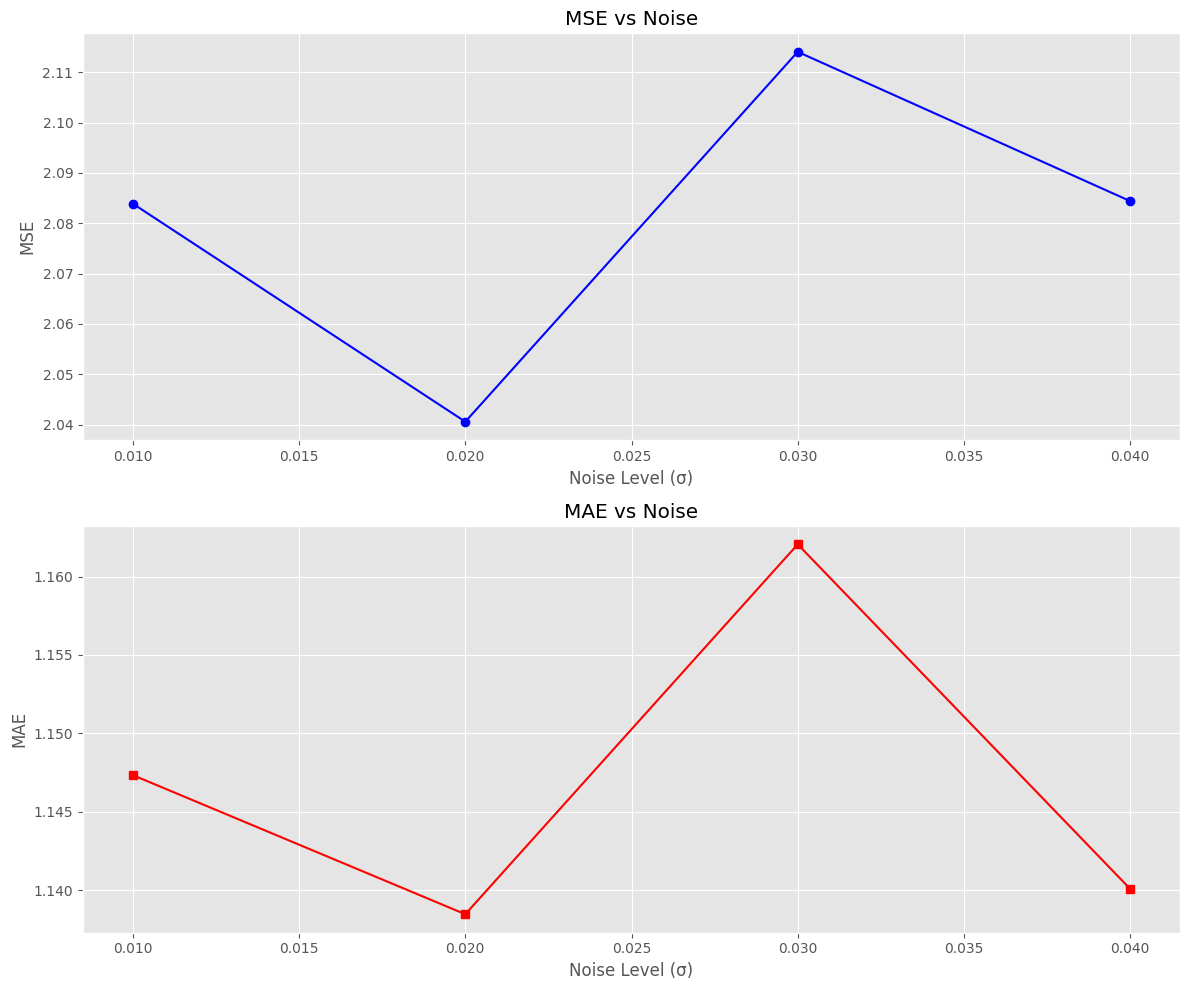

In [24]:
# 绘制噪声-性能曲线
plt.figure(figsize=(12, 10))
noise_levels = [r["noise_level"] for r in noise_results]
mse_values = [r["mse"] for r in noise_results]
mae_values = [r["mae"] for r in noise_results]

# 创建两个子图
plt.subplot(2, 1, 1)
plt.plot(noise_levels, mse_values, "o-", color="blue")
plt.title("MSE vs Noise")
plt.xlabel("Noise Level (σ)")
plt.ylabel("MSE")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(noise_levels, mae_values, "s-", color="red")
plt.title("MAE vs Noise")
plt.xlabel("Noise Level (σ)")
plt.ylabel("MAE")
plt.grid(True)

plt.tight_layout()
plt.show()